In [26]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.timeseries import LombScargle
from scipy.signal import periodogram, welch

## Simulated Data

In [27]:
# Make a regular time grid
time = np.linspace(0, 100, 1000)

# True period = 10 days
true_period = 10
flux = np.sin(2 * np.pi * time / true_period)

# Add noise
flux = flux + 0.3 * np.random.normal(size=len(time))

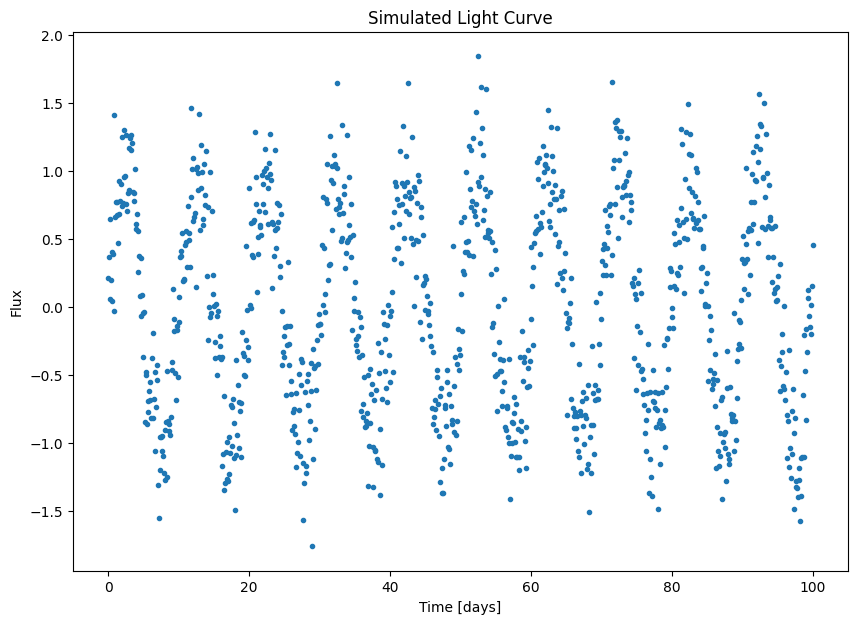

In [28]:
plt.figure(figsize=[10,7])
plt.errorbar(time, flux, fmt=".")
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Simulated Light Curve")
plt.show()

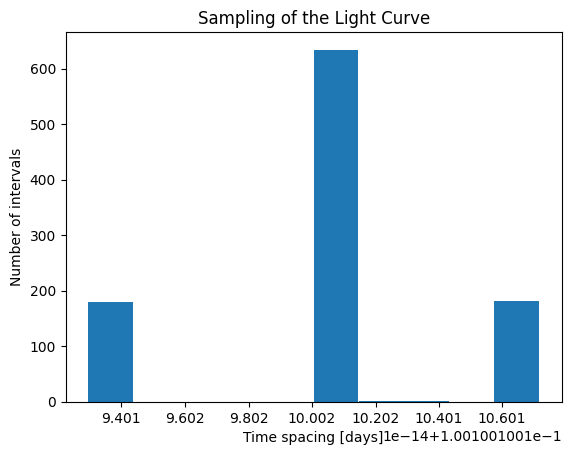

Median spacing: 0.10010010010010006 days
Minimum spacing: 0.10010010010009296 days
Maximum spacing: 0.10010010010010717 days


In [29]:
dt_diff = np.diff(time)

plt.hist(dt_diff)
plt.xlabel("Time spacing [days]")
plt.ylabel("Number of intervals")
plt.title("Sampling of the Light Curve")
plt.show()

print("Median spacing:", np.median(dt_diff), "days")
print("Minimum spacing:", np.min(dt_diff), "days")
print("Maximum spacing:", np.max(dt_diff), "days")

In [30]:
dt = np.median(dt_diff)
min_freq = 1/(time[-1] - time[0])
max_freq = 1/(2*dt)

print(dt, min_freq, max_freq)

0.10010010010010006 0.01 4.995000000000002


### FFT Method

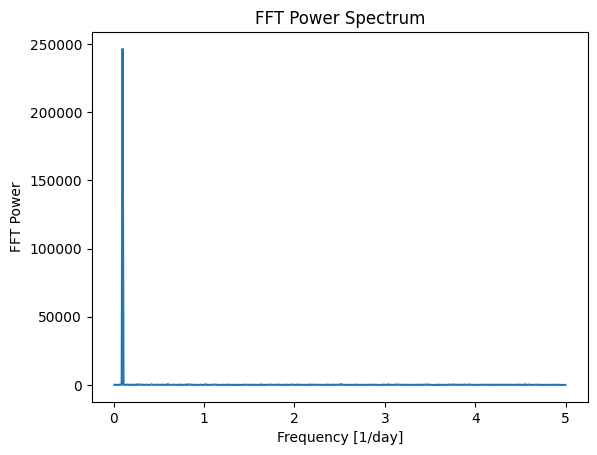

Best period from FFT: 10.010010010010006


In [31]:
freq = np.fft.rfftfreq(len(time), d=dt)
fft_values = np.fft.rfft(flux - np.mean(flux))
power = np.abs(fft_values)**2

plt.plot(freq[1:], power[1:])
plt.xlabel("Frequency [1/day]")
plt.ylabel("FFT Power")
plt.title("FFT Power Spectrum")
plt.show()

best_power = np.max(power[1:])
best_freq = freq[1:][np.argmax(power[1:])]
best_period = 1 / best_freq

print("Best period from FFT:", best_period)

### Periodogram Method

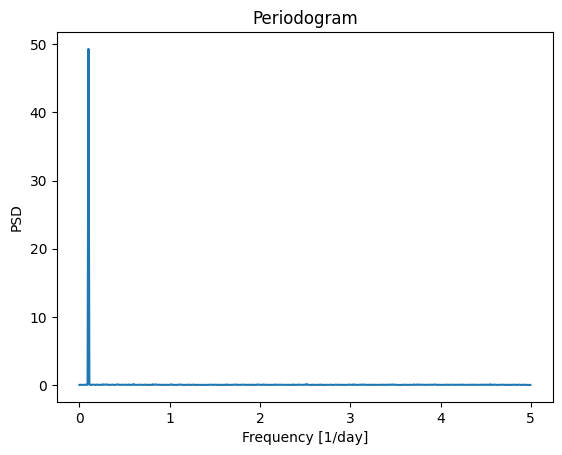

Best period from FFT: 10.010010010010006


In [32]:
fs = 1 / dt # sampling frequency, e.g. samples per day

freq_p, power_p = periodogram(
    flux,
    fs=fs,
    scaling="density"
)

plt.plot(freq_p, power_p)
plt.xlabel("Frequency [1/day]")
plt.ylabel("PSD")
plt.title("Periodogram")
plt.show()

best_power = np.max(power_p)
best_freq = freq_p[np.argmax(power_p)]
best_period = 1 / best_freq

print("Best period from FFT:", best_period)

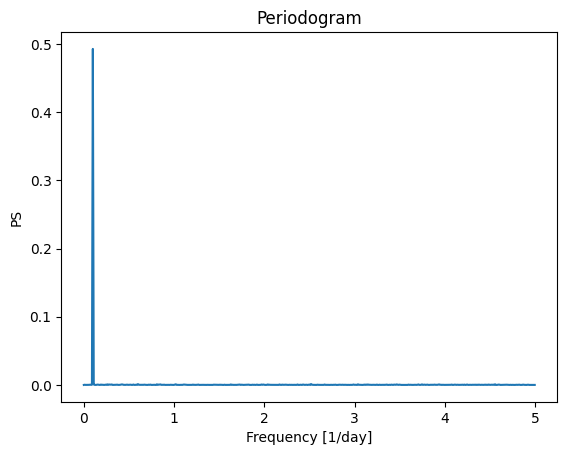

Best period from FFT: 10.010010010010006


In [33]:
fs = 1 / dt # sampling frequency, e.g. samples per day

freq_p, power_p = periodogram(
    flux,
    fs=fs,
    scaling="spectrum"
)

plt.plot(freq_p, power_p)
plt.xlabel("Frequency [1/day]")
plt.ylabel("PS")
plt.title("Periodogram")
plt.show()

best_power = np.max(power_p)
best_freq = freq_p[np.argmax(power_p)]
best_period = 1 / best_freq

print("Best period from FFT:", best_period)

### Welch Method

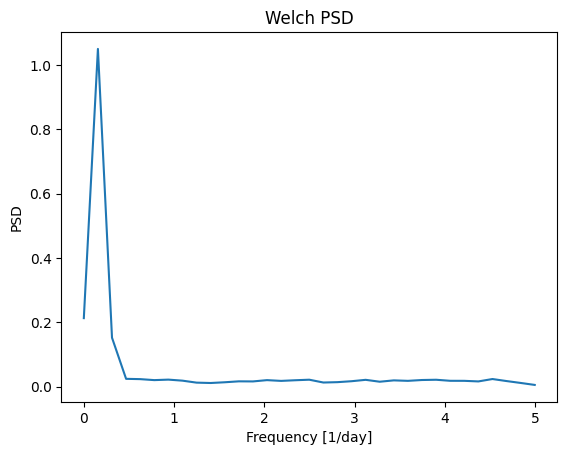

Best period from FFT: 6.406406406406404


In [34]:
freq_w, power_w = welch(
    flux,
    fs=fs,
    nperseg=min(64, len(flux)),
    scaling="density"
)

plt.plot(freq_w, power_w)
plt.xlabel("Frequency [1/day]")
plt.ylabel("PSD")
plt.title("Welch PSD")
plt.show()

best_power = np.max(power_w)
best_freq = freq_w[np.argmax(power_w)]
best_period = 1 / best_freq

print("Best period from FFT:", best_period)

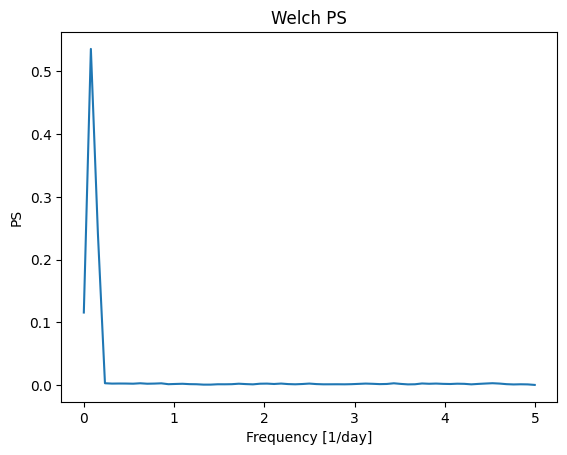

Best period from FFT: 100.10010010010006


In [35]:
freq_w, power_w = welch(
    flux,
    fs=fs,
    nperseg=min(128, len(flux)),
    scaling="spectrum"
)

plt.plot(freq_w, power_w)
plt.xlabel("Frequency [1/day]")
plt.ylabel("PS")
plt.title("Welch PS")
plt.show()

best_power = np.max(power_w)
best_freq = freq_p[np.argmax(power_w)]
best_period = 1 / best_freq

print("Best period from FFT:", best_period)

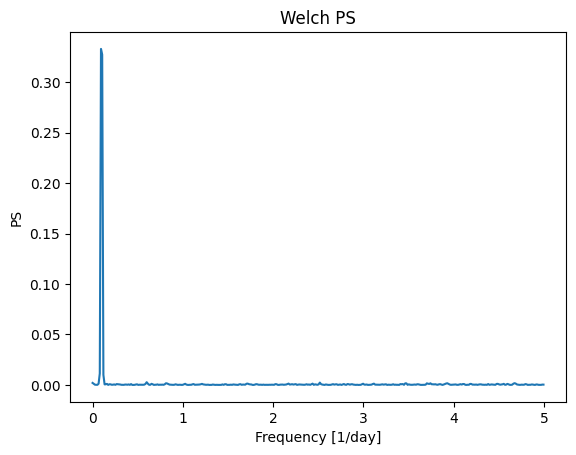

Best period from FFT: 14.300014300014293


In [36]:
freq_w, power_w = welch(
    flux,
    fs=fs,
    nperseg=min(750, len(flux)),
    scaling="spectrum"
)

plt.plot(freq_w, power_w)
plt.xlabel("Frequency [1/day]")
plt.ylabel("PS")
plt.title("Welch PS")
plt.show()

best_power = np.max(power_w)
best_freq = freq_p[np.argmax(power_w)]
best_period = 1 / best_freq

print("Best period from FFT:", best_period)

### Creating an uneven sampled lightcurve

In [37]:
# We introudce uneven data set as it is in the real world
np.random.seed(42)
mask = np.random.choice([True, False], size=len(time), p=[0.6, 0.4])

time_uneven = time[mask]
flux_uneven = flux[mask]

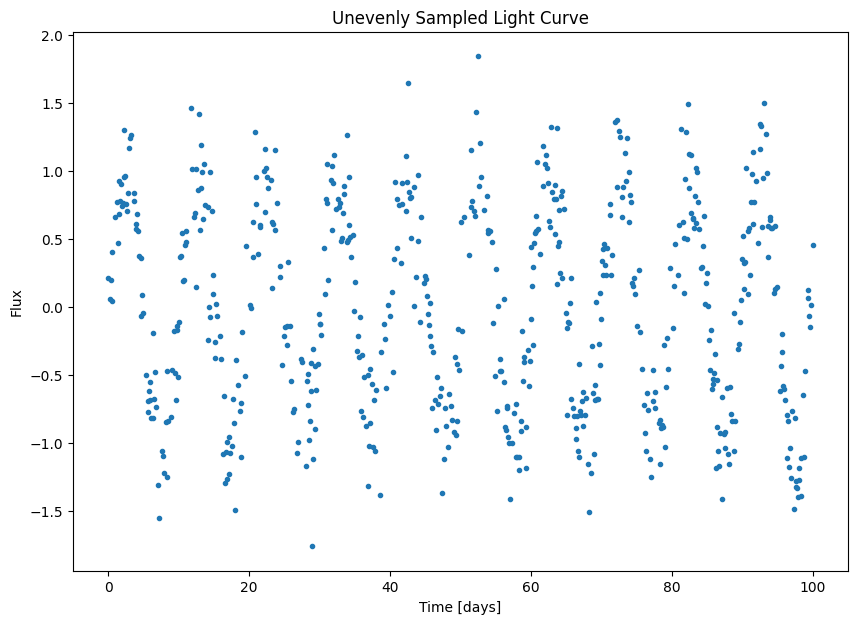

In [38]:
plt.figure(figsize=[10,7])
plt.plot(time_uneven, flux_uneven, ".")
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.title("Unevenly Sampled Light Curve")
plt.show()

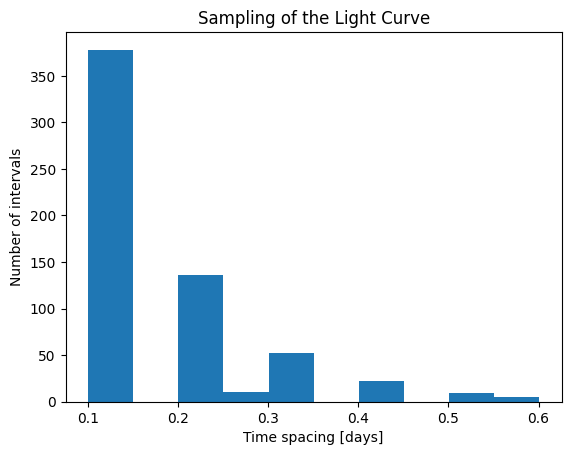

Median spacing: 0.10010010010010717 days
Minimum spacing: 0.10010010010009296 days
Maximum spacing: 0.6006006006006004 days


In [39]:
dt_diff = np.diff(time_uneven)

plt.hist(dt_diff)
plt.xlabel("Time spacing [days]")
plt.ylabel("Number of intervals")
plt.title("Sampling of the Light Curve")
plt.show()

print("Median spacing:", np.median(dt_diff), "days")
print("Minimum spacing:", np.min(dt_diff), "days")
print("Maximum spacing:", np.max(dt_diff), "days")

In [40]:
dt = np.min(dt_diff)
min_freq = 1/(time_uneven[-1] - time_uneven[0])
max_freq = 1/(2*dt)

print(dt, min_freq, max_freq)

0.10010010010009296 0.01 4.995000000000356


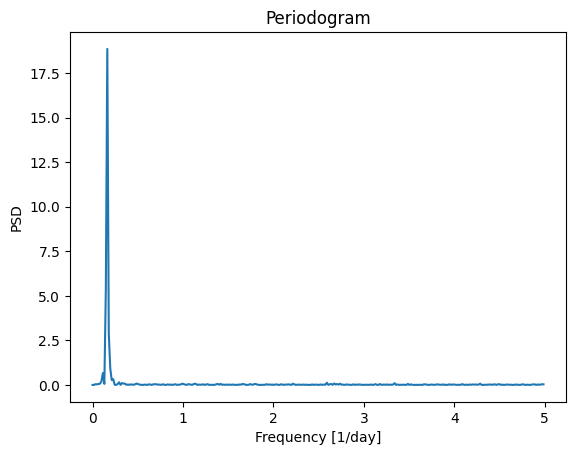

Best period from FFT: 6.136136136135698


In [41]:
fs = 1 / dt # sampling frequency, e.g. samples per day

freq_p, power_p = periodogram(
    flux_uneven,
    fs=fs,
    scaling="density"
)

plt.plot(freq_p, power_p)
plt.xlabel("Frequency [1/day]")
plt.ylabel("PSD")
plt.title("Periodogram")
plt.show()

best_power = np.max(power_p)
best_freq = freq_p[np.argmax(power_p)]
best_period = 1 / best_freq

print("Best period from FFT:", best_period)

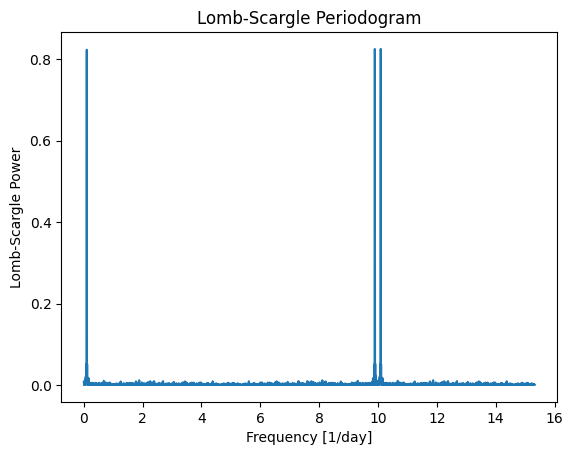

In [42]:
ls = LombScargle(time_uneven, flux_uneven)

frequency, power = ls.autopower()

plt.plot(frequency, power)
plt.xlabel("Frequency [1/day]")
plt.ylabel("Lomb-Scargle Power")
plt.title("Lomb-Scargle Periodogram")
plt.show()

In [43]:
best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq

print("Best period from Lomb-Scargle:", best_period)

false_alarm = ls.false_alarm_probability(power.max())

print(false_alarm)

Best period from Lomb-Scargle: 0.09909820632246558
3.342865926528233e-227


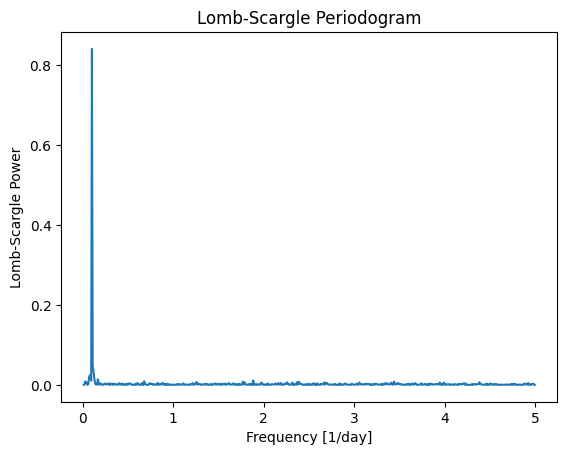

In [44]:
frequency = np.linspace(min_freq, max_freq, len(time_uneven))

ls = LombScargle(time_uneven, flux_uneven)

power = ls.power(frequency)

plt.plot(frequency, power)
plt.xlabel("Frequency [1/day]")
plt.ylabel("Lomb-Scargle Power")
plt.title("Lomb-Scargle Periodogram")
plt.show()



In [45]:
best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq

print("Best period from Lomb-Scargle:", best_period)

false_alarm = ls.false_alarm_probability(power.max())

print(false_alarm)

Best period from Lomb-Scargle: 10.04019358543123
1.4738169764561342e-239


## Fermi Example for PG 1553 Monthly Binned Data

In [46]:
data = Table.read('pg1553_monthly.csv', format='csv')
print(data.colnames)

['Date(UTC)', 'Julian Date', 'MET', 'TS', 'Photon Flux [0.1-100 GeV](photons cm-2 s-1)', 'Photon Flux Error(photons cm-2 s-1)']


In [47]:
data

Date(UTC),Julian Date,MET,TS,Photon Flux [0.1-100 GeV](photons cm-2 s-1),Photon Flux Error(photons cm-2 s-1)
str11,float64,int64,float64,float64,float64
Aug 19 2008,2454698.5,240883201,632.49,7.22e-08,6.8e-09
Sep 18 2008,2454728.5,243475201,366.78,5.09e-08,6.5e-09
Nov 17 2008,2454788.5,248659201,507.72,6.97e-08,7.5e-09
Dec 17 2008,2454818.5,251251201,631.78,6.18e-08,6.2e-09
Jan 16 2009,2454848.49998843,253843201,269.32,4.16e-08,5.8e-09
Feb 15 2009,2454878.49998843,256435201,339.27,3.74e-08,5.2e-09
Mar 17 2009,2454908.49998843,259027201,160.2,3.01e-08,5.3e-09
Apr 16 2009,2454938.49998843,261619201,170.24,3.09e-08,5.1e-09
May 16 2009,2454968.49998843,264211201,295.92,3.87e-08,5.4e-09


In [48]:
print(data['Date(UTC)'])

 Date(UTC) 
-----------
Aug 19 2008
Sep 18 2008
Nov 17 2008
Dec 17 2008
Jan 16 2009
Feb 15 2009
Mar 17 2009
Apr 16 2009
May 16 2009
Jun 15 2009
        ...
Jun 21 2025
Jul 21 2025
Aug 20 2025
Sep 19 2025
Oct 19 2025
Nov 18 2025
Dec 18 2025
Jan 17 2026
Feb 16 2026
Mar 18 2026
Length = 214 rows


In [49]:
date = Time.strptime(data['Date(UTC)'], '%b %d %Y')
print(date)

['2008-08-19T00:00:00.000' '2008-09-18T00:00:00.000'
 '2008-11-17T00:00:00.000' '2008-12-17T00:00:00.000'
 '2009-01-16T00:00:00.000' '2009-02-15T00:00:00.000'
 '2009-03-17T00:00:00.000' '2009-04-16T00:00:00.000'
 '2009-05-16T00:00:00.000' '2009-06-15T00:00:00.000'
 '2009-07-15T00:00:00.000' '2009-08-14T00:00:00.000'
 '2009-09-13T00:00:00.000' '2009-10-13T00:00:00.000'
 '2009-11-12T00:00:00.000' '2009-12-12T00:00:00.000'
 '2010-01-11T00:00:00.000' '2010-02-10T00:00:00.000'
 '2010-03-12T00:00:00.000' '2010-04-11T00:00:00.000'
 '2010-05-11T00:00:00.000' '2010-06-10T00:00:00.000'
 '2010-07-10T00:00:00.000' '2010-08-09T00:00:00.000'
 '2010-09-08T00:00:00.000' '2010-10-08T00:00:00.000'
 '2010-11-07T00:00:00.000' '2010-12-07T00:00:00.000'
 '2011-01-06T00:00:00.000' '2011-02-05T00:00:00.000'
 '2011-03-07T00:00:00.000' '2011-04-06T00:00:00.000'
 '2011-05-06T00:00:00.000' '2011-06-05T00:00:00.000'
 '2011-07-05T00:00:00.000' '2011-08-04T00:00:00.000'
 '2011-09-03T00:00:00.000' '2011-10-03T00:00:0

In [50]:
date_jyear = date.to_value('jyear', subfmt='float')
print(date_jyear)

[2008.63107461 2008.71321013 2008.87748118 2008.9596167  2009.04175222
 2009.12388775 2009.20602327 2009.2881588  2009.37029432 2009.45242984
 2009.53456537 2009.61670089 2009.69883641 2009.78097194 2009.86310746
 2009.94524298 2010.02737851 2010.10951403 2010.19164956 2010.27378508
 2010.3559206  2010.43805613 2010.52019165 2010.60232717 2010.6844627
 2010.76659822 2010.84873374 2010.93086927 2011.01300479 2011.09514031
 2011.17727584 2011.25941136 2011.34154689 2011.42368241 2011.50581793
 2011.58795346 2011.67008898 2011.7522245  2011.83436003 2011.91649555
 2011.99863107 2012.0807666  2012.16290212 2012.24503765 2012.32717317
 2012.40930869 2012.49144422 2012.57357974 2012.65571526 2012.73785079
 2012.81998631 2012.90212183 2012.98425736 2013.06639288 2013.14852841
 2013.23066393 2013.31279945 2013.39493498 2013.4770705  2013.55920602
 2013.64134155 2013.72347707 2013.80561259 2013.88774812 2013.96988364
 2014.05201916 2014.13415469 2014.21629021 2014.29842574 2014.38056126
 2014.4

In [51]:
date_jyear_correction = date_jyear - date_jyear[0]

time_met = np.array(data['MET']) ## Time in Instrument Seconds
time_yr = time_met/(3600*24*365)
time_yr_correction = time_yr - time_yr[0]

flux = data['Photon Flux [0.1-100 GeV](photons cm-2 s-1)']
flux_err = data['Photon Flux Error(photons cm-2 s-1)']

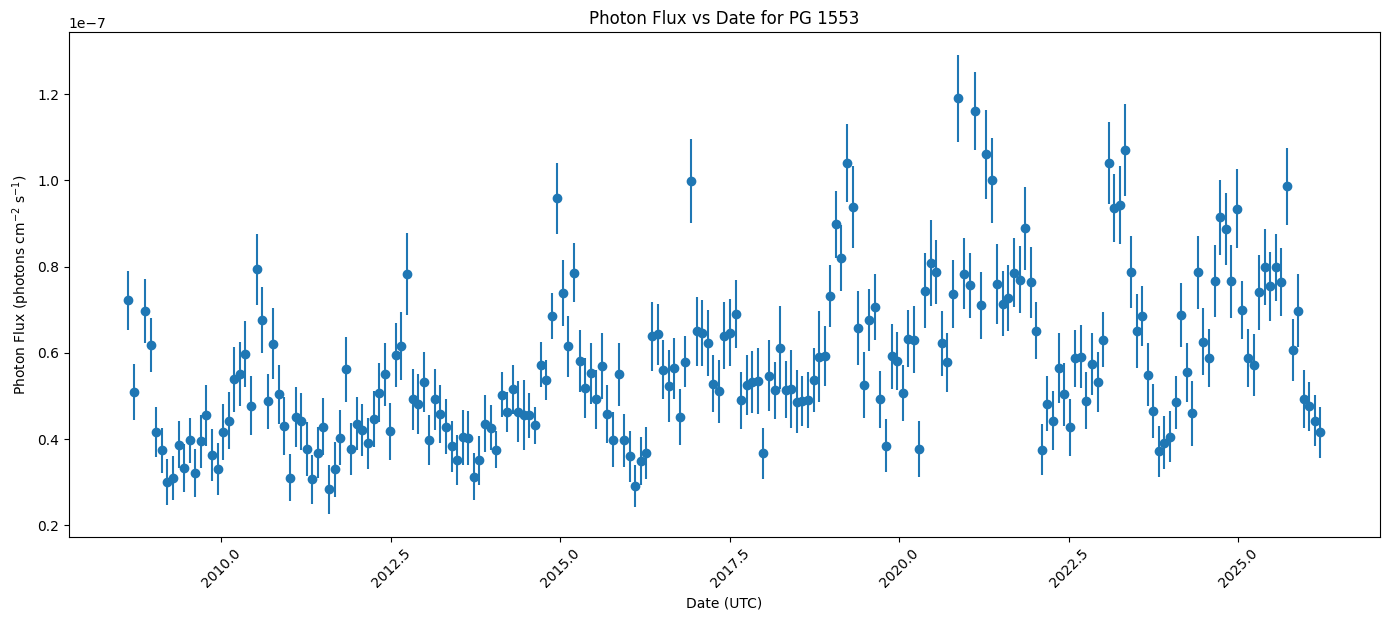

In [52]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.errorbar(date_jyear, flux, yerr=flux_err, fmt='o')
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Photon Flux (photons cm$^{-2}$ s$^{-1}$)')
ax.set_title('Photon Flux vs Date for PG 1553')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

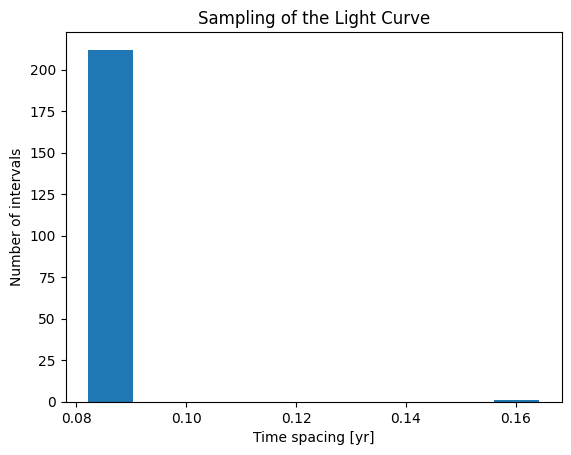

Median spacing: 0.0821355236139425 yr
Minimum spacing: 0.0821355236139425 yr
Maximum spacing: 0.164271047227885 yr


In [53]:
dt_diff = np.diff(date_jyear_correction)

plt.hist(dt_diff)
plt.xlabel("Time spacing [yr]")
plt.ylabel("Number of intervals")
plt.title("Sampling of the Light Curve")
plt.show()

print("Median spacing:", np.median(dt_diff), "yr")
print("Minimum spacing:", np.min(dt_diff), "yr")
print("Maximum spacing:", np.max(dt_diff), "yr")

In [54]:
# Check if all values in flux and flux_err are floats
print("Are all values in flux floats?", np.all([isinstance(val, float) for val in flux]))
print("Are all values in flux_err floats?", np.all([isinstance(val, float) for val in flux_err]))

Are all values in flux floats? True
Are all values in flux_err floats? True


In [55]:
mask = (
    np.isfinite(date_jyear_correction)    ## Check for infinite values
    & np.isfinite(flux)                   ## Check for infinite values
    & np.isfinite(flux_err)               ## Check for infinite values
    & (flux > 0)                          ## Check for positive and physical values
    & (flux_err > 0)                      ## Check for positive and physical values
    & (~np.isnan(date_jyear_correction))  ## Check the values exist or is there any empty element
    & (~np.isnan(flux))                   ## Check the values exist or is there any empty element
    & (~np.isnan(flux_err))               ## Check the values exist or is there any empty element
)

time_clean = date_jyear_correction[mask]
flux_clean = flux[mask]
flux_err_clean = flux_err[mask]
time_yr_clean = time_yr_correction[mask]

flux_clean = flux_clean - np.mean(flux_clean)

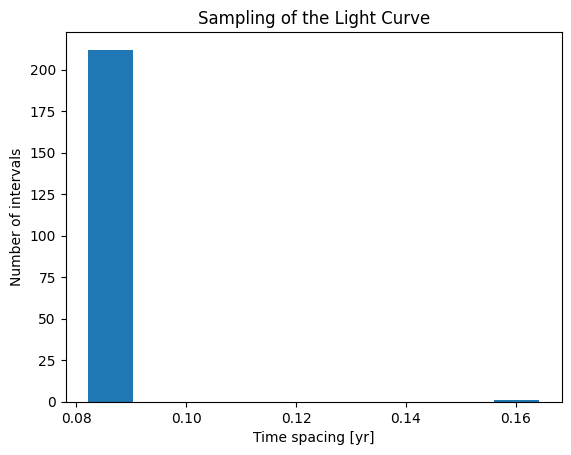

Median spacing: 0.0821355236139425 yr
Minimum spacing: 0.0821355236139425 yr
Maximum spacing: 0.164271047227885 yr


In [56]:
dt_diff = np.diff(time_clean)

plt.hist(dt_diff)
plt.xlabel("Time spacing [yr]")
plt.ylabel("Number of intervals")
plt.title("Sampling of the Light Curve")
plt.show()

print("Median spacing:", np.median(dt_diff), "yr")
print("Minimum spacing:", np.min(dt_diff), "yr")
print("Maximum spacing:", np.max(dt_diff), "yr")

In [57]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.errorbar(time_clean, flux_clean, yerr=flux_err_clean, fmt='o', label='Year Time')
ax.errorbar(time_yr_clean, flux_clean, yerr=flux_err_clean, fmt='o', label='MET Time')
ax.set_xlabel(f'Time (yr) since {date.to_value('iso', subfmt='date')[0]}')
ax.set_ylabel('Photon Flux (photons cm$^{-2}$ s$^{-1}$)')
ax.set_title('Photon Flux vs Date for PG 1553')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

SyntaxError: f-string: unmatched '(' (3067824926.py, line 4)

There is some shift in Orange data because we are using not using the accurate defination for time conversion from seconds --> year

#### Period and Frequency from Literature: 2.2 yr, Freq = 0.45 $yr^{-1}$, for August 2008 - October 2017

In [ ]:
dt = np.min(dt_diff)
min_freq = 1/(time_clean[-1] - time_clean[0])
max_freq = 1/(2*dt)

print(dt, min_freq, max_freq)

In [ ]:
freq_fft = np.fft.rfftfreq(len(flux_clean), d=dt)
fft_values = np.fft.rfft(flux_clean)
power_fft = np.abs(fft_values)**2

plt.plot(freq_fft, power_fft)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("FFT Power")
plt.title("FFT Power Spectrum")
plt.show()

In [ ]:
fs = 1 / dt # sampling frequency, e.g. samples per yr

freq_p, power_p = periodogram(
    flux_clean,
    fs=fs,
    scaling="density"
)

plt.plot(freq_p, power_p)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Periodogram")
plt.show()

In [ ]:
fs = 1 / dt # sampling frequency, e.g. samples per yr

freq_p, power_p = periodogram(
    flux_clean,
    fs=fs,
    scaling="spectrum"
)

plt.plot(freq_p, power_p)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Periodogram")
plt.show()

In [ ]:
freq_w, power_w = welch(
    flux_clean,
    fs=fs,
    nperseg=min(128, len(flux_clean)),
    scaling="density"
)

plt.plot(freq_w, power_w)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Welch PSD")
plt.show()

In [ ]:
freq_w, power_w = welch(
    flux_clean,
    fs=fs,
    nperseg=min(64, len(flux_clean)),
    scaling="density"
)

plt.plot(freq_w, power_w)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Welch PSD")
plt.show()

In [ ]:
freq_w, power_w = welch(
    flux_clean,
    fs=fs,
    nperseg=min(512, len(flux_clean)),
    scaling="density"
)

plt.plot(freq_w, power_w)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Welch PSD")
plt.show()

In [ ]:
ls = LombScargle(time_clean, flux_clean, flux_err_clean)

frequency, power = ls.autopower()

plt.plot(frequency, power)
plt.xscale('log')
plt.xlabel("Frequency [1/yr]")
plt.ylabel("Lomb-Scargle Power")
plt.title("Lomb-Scargle Periodogram")
plt.show()



In [ ]:
best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq

print("Best period from Lomb-Scargle:", best_period)

false_alarm = ls.false_alarm_probability(power.max())

print(false_alarm)

In [ ]:
frequency_ls = np.linspace(min_freq, max_freq, len(time_clean))

ls = LombScargle(time_clean, flux_clean, flux_err_clean)

power_ls = ls.power(frequency_ls)

plt.plot(frequency_ls, power_ls)
plt.xscale('log')
plt.xlabel("Frequency [1/yr]")
plt.ylabel("Lomb-Scargle Power")
plt.title("Lomb-Scargle Periodogram")
plt.show()

In [ ]:
best_frequency = frequency_ls[np.argmax(power_ls)]
best_period = 1 / best_frequency

print("Best frequency:", best_frequency, "1/yr")
print("Best period:", best_period, "yr")

false_alarm = ls.false_alarm_probability(power_ls.max())

print(false_alarm)

## Fermi Example for PG 1553 Weekly Binned Data

In [ ]:
data = Table.read('pg1553_weekly.csv', format='csv')
print(data.colnames)

In [ ]:
data

In [ ]:
date = Time.strptime(data['Date(UTC)'], '%b %d %Y')
date_jyear = date.to_value('jyear', subfmt='float')
date_jyear_correction = date_jyear - date_jyear[0]
time_met = np.array(data['MET'])
time_yr = time_met/(3600*24*365)
time_yr_correction = time_yr - time_yr[0]

flux = data['Photon Flux [0.1-100 GeV](photons cm-2 s-1)'].value.copy()
flux_err = data['Photon Flux Error(photons cm-2 s-1)'].value.copy()

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.errorbar(date_jyear, flux, fmt='o')
ax.set_xlabel('Date (UTC)')
ax.set_ylabel('Photon Flux (photons cm$^{-2}$ s$^{-1}$)')
ax.set_title('Photon Flux vs Date for PG 1553')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

Did you all notice something ??

In [ ]:
flux = data['Photon Flux [0.1-100 GeV](photons cm-2 s-1)'].value.copy()
flux_err = data['Photon Flux Error(photons cm-2 s-1)'].value.copy()

In [ ]:
# Check if all values in flux and flux_err are floats
print("Are all values in flux floats?", np.all([isinstance(val, float) for val in flux]))
print("Are all values in flux_err floats?", np.all([isinstance(val, float) for val in flux_err]))

In [ ]:
# Clean string and non-float values in flux and flux_err, only keep float/finite values
# First, convert all entries to floats if possible, otherwise NaN
def safe_float(val):
    try:
        if isinstance(val, str):
            parts = val.strip().split()
            if len(parts) == 1:
                return float(parts[0])
            elif len(parts) == 2:
                # Original intent: treat these as bad, set nan
                return np.nan
            else:
                return np.nan
        else:
            return float(val)
    except:
        return np.nan

flux_cleaned = np.array([safe_float(v) for v in flux])
flux_err_cleaned = np.array([safe_float(v) for v in flux_err])

# Now build mask using only cleaned float arrays
mask = (
    np.isfinite(date_jyear_correction)
    & np.isfinite(flux_cleaned)
    & np.isfinite(flux_err_cleaned)
    & (flux_cleaned > 0)
    & (flux_err_cleaned > 0)
    & (~np.isnan(date_jyear_correction))
    & (~np.isnan(flux_cleaned))
    & (~np.isnan(flux_err_cleaned))
)

# Apply mask to all arrays
time_clean = date_jyear_correction[mask]
flux_clean = flux_cleaned[mask]
flux_err_clean = flux_err_cleaned[mask]
time_yr_clean = time_yr_correction[mask]

flux_clean = flux_clean - np.mean(flux_clean)

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.errorbar(time_clean, flux_clean, yerr=flux_err_clean, fmt='o', label='Year Time')
ax.errorbar(time_yr_clean, flux_clean, yerr=flux_err_clean, fmt='o', label='MET Time')
ax.set_xlabel(f'Time (yr) since {date.to_value('iso', subfmt='date')[0]}')
ax.set_ylabel('Photon Flux (photons cm$^{-2}$ s$^{-1}$)')
ax.set_title('Photon Flux vs Date for PG 1553')
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [ ]:
dt_diff = np.diff(time_clean)

plt.hist(dt_diff)
plt.xlabel("Time spacing [yr]")
plt.ylabel("Number of intervals")
plt.title("Sampling of the Light Curve")
plt.show()

print("Median spacing:", np.median(dt_diff), "yr")
print("Minimum spacing:", np.min(dt_diff), "yr")
print("Maximum spacing:", np.max(dt_diff), "yr")

#### Period and Frequency from Literature: 2.2 yr, Freq = 0.45 $yr^{-1}$, for August 2008 - October 2017

In [ ]:
dt = np.min(dt_diff)
min_freq = 1/(time_clean[-1] - time_clean[0])
max_freq = 1/(2*dt)

print(dt, min_freq, max_freq)

In [ ]:
freq_fft = np.fft.rfftfreq(len(flux_clean), d=dt)
fft_values = np.fft.rfft(flux_clean)
power_fft = np.abs(fft_values)**2

plt.plot(freq_fft, power_fft)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("FFT Power")
plt.title("FFT Power Spectrum")
plt.show()

In [ ]:
fs = 1 / dt # sampling frequency, e.g. samples per yr

freq_p, power_p = periodogram(
    flux_clean,
    fs=fs,
    scaling="density"
)

plt.plot(freq_p, power_p)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Periodogram")
plt.show()

In [ ]:
fs = 1 / dt # sampling frequency, e.g. samples per yr

freq_p, power_p = periodogram(
    flux_clean,
    fs=fs,
    scaling="spectrum"
)

plt.plot(freq_p, power_p)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Periodogram")
plt.show()

In [ ]:
freq_w, power_w = welch(
    flux_clean,
    fs=fs,
    nperseg=min(128, len(flux_clean)),
    scaling="density"
)

plt.plot(freq_w, power_w)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Welch PSD")
plt.show()

In [ ]:
freq_w, power_w = welch(
    flux_clean,
    fs=fs,
    nperseg=min(64, len(flux_clean)),
    scaling="density"
)

plt.plot(freq_w, power_w)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Welch PSD")
plt.show()

In [ ]:
freq_w, power_w = welch(
    flux_clean,
    fs=fs,
    nperseg=min(512, len(flux_clean)),
    scaling="density"
)

plt.plot(freq_w, power_w)
plt.xlim(min_freq, max_freq)
plt.xlabel("Frequency [1/yr]")
plt.ylabel("PSD")
plt.title("Welch PSD")
plt.show()

In [ ]:
ls = LombScargle(time_clean, flux_clean, flux_err_clean)

frequency, power = ls.autopower()

plt.plot(frequency, power)
plt.xscale('log')
plt.xlabel("Frequency [1/yr]")
plt.ylabel("Lomb-Scargle Power")
plt.title("Lomb-Scargle Periodogram")
plt.show()



In [ ]:
best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

print("Best frequency:", best_frequency, "1/yr")
print("Best period:", best_period, "yr")

false_alarm = ls.false_alarm_probability(power.max())

print(false_alarm)

In [ ]:
frequency_ls = np.linspace(min_freq, max_freq, len(time_clean))

ls = LombScargle(time_clean, flux_clean, flux_err_clean)

power_ls = ls.power(frequency_ls)

plt.plot(frequency_ls, power_ls)
plt.xscale('log')
plt.xlabel("Frequency [1/yr]")
plt.ylabel("Lomb-Scargle Power")
plt.title("Lomb-Scargle Periodogram")
plt.show()

In [ ]:
best_frequency = frequency_ls[np.argmax(power_ls)]
best_period = 1 / best_frequency

print("Best frequency:", best_frequency, "1/yr")
print("Best period:", best_period, "yr")

false_alarm = ls.false_alarm_probability(power_ls.max())

print(false_alarm)